In [1]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

import re

# Manipulación de Textos

In [2]:
texto = "tasa bar\t banco \tpez"

Asume blancos por espacios, tabuladores o saltos de línea y aplica la separación entre ellos

In [4]:
re.split(r"\s+", texto)

['tasa', 'bar', 'banco', 'pez']

In [6]:
pattern = re.compile(r"\s+")

pattern

re.compile(r'\s+', re.UNICODE)

In [7]:
pattern.split(texto)

['tasa', 'bar', 'banco', 'pez']

In [8]:
pattern.findall(texto)

[' ', '\t ', ' \t']

## Ejercicio - Lista UAMI

In [63]:
uami = pandas.read_csv("lista_uami.txt", sep="\t", skiprows=11)

uami.head(10)

,RENGLON,MATRICULA,NOMBRE,CORREO ELECTRÓNICO
0,1,22420196,ALCANTARA JARDINES DANIEL YHOSHUA Danielalcant...,NaN
1,2,22330537,BAUTISTA PALOMARES XIMENA JAZMIN ximenapbe1@gm...,NaN
2,3,22120176,CARRASCO SANCHEZ ERIK BRAYAN erikbr60788@gmail...,NaN
3,4,22420184,CASTRO LOERA GABRIEL gblra@hotmail.com,NaN
4,5,22420189,CEBALLOS JIMENEZ NATALIA natji15@gmail.com,NaN
5,6,22430143,CHIMA SANTIAGO LIZBETH JOSELIN betthiagooo@gma...,NaN
6,7,22420186,CRUZ ALVARADO JESUS SAID jesussc23@gmail.com,NaN
7,8,22420193,CRUZ ANGULO CAMILA DESIREE odetconcelos5496@gm...,NaN
8,9,22420183,CRUZ REYES JOSE SALVADOR bmtcketcore@gmail.com,NaN
9,10,22420186,CRUZ ZARAGOZA DIEGO tacotruvb.1@gmail.com,NaN


In [64]:
uami.iloc[0, 2]

'ALCANTARA JARDINES DANIEL YHOSHUA Danielalcantaraj@gmail.com'

In [65]:
pattern_correo = re.compile(r"[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,4}", flags=re.IGNORECASE)

pattern_correo

re.compile(r'[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,4}', re.IGNORECASE|re.UNICODE)

In [66]:
uami["NOMBRE"].map(lambda s: pattern_correo.search(s).group(0).lower()).head()

0    danielalcantaraj@gmail.com
1          ximenapbe1@gmail.com
2         erikbr60788@gmail.com
3             gblra@hotmail.com
4             natji15@gmail.com
Name: NOMBRE, dtype: object

In [67]:
uami["NOMBRE"].map(lambda s: pattern_correo.split(s)[0].strip()).head()

0    ALCANTARA JARDINES DANIEL YHOSHUA
1     BAUTISTA PALOMARES XIMENA JAZMIN
2         CARRASCO SANCHEZ ERIK BRAYAN
3                 CASTRO LOERA GABRIEL
4             CEBALLOS JIMENEZ NATALIA
Name: NOMBRE, dtype: object

In [68]:
uami["CORREO ELECTRÓNICO"] = uami["NOMBRE"].map(lambda s: pattern_correo.search(s).group(0).lower())
uami["NOMBRE"] = uami["NOMBRE"].map(lambda s: pattern_correo.split(s)[0].strip())

uami.head()

,RENGLON,MATRICULA,NOMBRE,CORREO ELECTRÓNICO
0,1,22420196,ALCANTARA JARDINES DANIEL YHOSHUA,danielalcantaraj@gmail.com
1,2,22330537,BAUTISTA PALOMARES XIMENA JAZMIN,ximenapbe1@gmail.com
2,3,22120176,CARRASCO SANCHEZ ERIK BRAYAN,erikbr60788@gmail.com
3,4,22420184,CASTRO LOERA GABRIEL,gblra@hotmail.com
4,5,22420189,CEBALLOS JIMENEZ NATALIA,natji15@gmail.com


### Partes de un correo

In [74]:
uami["CORREO ELECTRÓNICO"].str.extract(r"([^@]+)@([^.]+)\.(.*)")

,0,1,2
0,danielalcantaraj,gmail,com
1,ximenapbe1,gmail,com
2,erikbr60788,gmail,com
3,gblra,hotmail,com
4,natji15,gmail,com
5,betthiagooo,gmail,com
6,jesussc23,gmail,com
7,odetconcelos5496,gmail,com
8,bmtcketcore,gmail,com
9,tacotruvb.1,gmail,com


In [80]:
reporte = pandas.DataFrame(uami["CORREO ELECTRÓNICO"].str.extract(r"([^@]+)@([^.]+)\.(.*)"))

reporte.columns = ["nombre", "servicio", "dominio"]

reporte

,nombre,servicio,dominio
0,danielalcantaraj,gmail,com
1,ximenapbe1,gmail,com
2,erikbr60788,gmail,com
3,gblra,hotmail,com
4,natji15,gmail,com
5,betthiagooo,gmail,com
6,jesussc23,gmail,com
7,odetconcelos5496,gmail,com
8,bmtcketcore,gmail,com
9,tacotruvb.1,gmail,com


In [83]:
reporte.groupby("servicio").size()

servicio
gmail      46
hotmail     2
icloud      1
outlook     1
dtype: int64

## Ejercicio - Natalidad

In [127]:
natalidad = pandas.read_excel("natalidad.xlsx", skiprows=7, usecols="A,Z:AB", nrows=32,
                              names=["Estado", "Hombres", "Mujeres", "No Especificado"], 
                              index_col=0)

natalidad.head()

,Hombres,Mujeres,No Especificado
Estado,,,
Aguascalientes,10317,9779,0
Baja California,32022,30881,0
Baja California Sur,5297,5222,0
Campeche,6739,6641,0
Coahuila de Zaragoza,22311,21529,0


In [128]:
natalidadA = natalidad.loc["Aguascalientes":"Durango"]
natalidadB = natalidad.loc["Guanajuato":"Oaxaca"]
natalidadC = natalidad.loc["Puebla":"Zacatecas"]

natalidadA.head(), natalidadB.head(), natalidadC.head()

(                      Hombres  Mujeres  No Especificado
 Estado                                                 
 Aguascalientes          10317     9779                0
 Baja California         32022    30881                0
 Baja California Sur      5297     5222                0
 Campeche                 6739     6641                0
 Coahuila de Zaragoza    22311    21529                0,
             Hombres  Mujeres  No Especificado
 Estado                                       
 Guanajuato    46831    45666                1
 Guerrero      32264    32054                0
 Hidalgo       18522    18275                0
 Jalisco       64624    62413                0
 México       106235   103932                0,
                  Hombres  Mujeres  No Especificado
 Estado                                            
 Puebla             53856    52479                0
 Querétaro          15823    15067                0
 Quintana Roo       12739    12386                0
 San Luis 

In [129]:
pandas.concat([natalidadA, natalidadB, natalidadC], keys=["Grupo A", "Grupo B", "Grupo C"])

Hombres  Mujeres  No Especificado
        Estado                                                            
Grupo A Aguascalientes                     10317     9779                0
        Baja California                    32022    30881                0
        Baja California Sur                 5297     5222                0
        Campeche                            6739     6641                0
        Coahuila de Zaragoza               22311    21529                0
        Colima                              4464     4385                0
        Chiapas                            75386    74549                0
        Chihuahua                          25618    24902                1
        Ciudad de México                   43319    42057                0
        Durango                            15208    14657                0
Grupo B Guanajuato                         46831    45666                1
        Guerrero                           32264    32054                0
        Hidalgo                            18522    18275                0
        Jalisco                            64624    62413                0
        México                            106235   103932                0
        Michoacán de Ocampo                38395    37274                0
        Morelos                            12153    12111                0
        Nayarit                             8996     8523                0
        Nuevo León                         40517    39232                0
        Oaxaca                             34726    33834                0
Grupo C Puebla                             53856    52479                0
        Querétaro                          15823    15067                0
        Quintana Roo                       12739    12386                0
        San Luis Potosí                    20758    20050                0
        Sinaloa                            22694    21787                0
        Sonora                             19158    18313                0
        Tabasco                            18611    18261                0
        Tamaulipas                         22507    21831                0
        Tlaxcala                            9844     9637                0
        Veracruz de Ignacio de la Llave    50628    49154                0
        Yucatán                            13464    13037                0
        Zacatecas                          12705    12373                0

In [134]:
pandas.concat([natalidadA, natalidadB, natalidadC], 
              axis="columns",
              keys=["Grupo A", "Grupo B", "Grupo C"])

Grupo A                            Grupo B  \
                                 Hombres  Mujeres No Especificado   Hombres   
Estado                                                                        
Aguascalientes                   10317.0   9779.0             0.0       NaN   
Baja California                  32022.0  30881.0             0.0       NaN   
Baja California Sur               5297.0   5222.0             0.0       NaN   
Campeche                          6739.0   6641.0             0.0       NaN   
Coahuila de Zaragoza             22311.0  21529.0             0.0       NaN   
Colima                            4464.0   4385.0             0.0       NaN   
Chiapas                          75386.0  74549.0             0.0       NaN   
Chihuahua                        25618.0  24902.0             1.0       NaN   
Ciudad de México                 43319.0  42057.0             0.0       NaN   
Durango                          15208.0  14657.0             0.0       NaN   
Guanajuato                           NaN      NaN             NaN   46831.0   
Guerrero                             NaN      NaN             NaN   32264.0   
Hidalgo                              NaN      NaN             NaN   18522.0   
Jalisco                              NaN      NaN             NaN   64624.0   
México                               NaN      NaN             NaN  106235.0   
Michoacán de Ocampo                  NaN      NaN             NaN   38395.0   
Morelos                              NaN      NaN             NaN   12153.0   
Nayarit                              NaN      NaN             NaN    8996.0   
Nuevo León                           NaN      NaN             NaN   40517.0   
Oaxaca                               NaN      NaN             NaN   34726.0   
Puebla                               NaN      NaN             NaN       NaN   
Querétaro                            NaN      NaN             NaN       NaN   
Quintana Roo                         NaN      NaN             NaN       NaN   
San Luis Potosí                      NaN      NaN             NaN       NaN   
Sinaloa                              NaN      NaN             NaN       NaN   
Sonora                               NaN      NaN             NaN       NaN   
Tabasco                              NaN      NaN             NaN       NaN   
Tamaulipas                           NaN      NaN             NaN       NaN   
Tlaxcala                             NaN      NaN             NaN       NaN   
Veracruz de Ignacio de la Llave      NaN      NaN             NaN       NaN   
Yucatán                              NaN      NaN             NaN       NaN   
Zacatecas                            NaN      NaN             NaN       NaN   

                                                           Grupo C           \
                                  Mujeres No Especificado  Hombres  Mujeres   
Estado                                                                        
Aguascalientes                        NaN             NaN      NaN      NaN   
Baja California                       NaN             NaN      NaN      NaN   
Baja California Sur                   NaN             NaN      NaN      NaN   
Campeche                              NaN             NaN      NaN      NaN   
Coahuila de Zaragoza                  NaN             NaN      NaN      NaN   
Colima                                NaN             NaN      NaN      NaN   
Chiapas                               NaN             NaN      NaN      NaN   
Chihuahua                             NaN             NaN      NaN      NaN   
Ciudad de México                      NaN             NaN      NaN      NaN   
Durango                               NaN             NaN      NaN      NaN   
Guanajuato                        45666.0             1.0      NaN      NaN   
Guerrero                          32054.0             0.0      NaN      NaN   
Hidalgo                           18275.0             0.0      NaN      NaN   
Jal

In [148]:
natalidad = pandas.read_excel("natalidad.xlsx", skiprows=6, usecols="A:AB", nrows=33, 
                              index_col=0)[1:]

natalidad.tail()

,2015,2015.1,2015.2,2016,2016.1,2016.2,2017,2017.1,2017.2,2018,...,2020.2,2021,2021.1,2021.2,2022,2022.1,2022.2,2023,2023.1,2023.2
Estado,,,,,,,,,,,,,,,,,,,,,
Tamaulipas,30807,29456,0,29794,29120,0,28836,28446,0,29139,...,0,25089,23959,0,24110,23177,0,22507,21831,0
Tlaxcala,13309,12857,0,12745,12312,0,13397,13192,0,12474,...,0,10260,10035,0,9964,9653,1,9844,9637,0
Veracruz de Ignacio de la Llave,73444,71398,0,69861,67477,0,64516,62107,0,63218,...,0,53582,51455,0,55329,53782,0,50628,49154,0
Yucatán,18780,18336,1,18067,17314,0,17917,17100,0,17996,...,0,14138,13926,0,14103,13829,0,13464,13037,0
Zacatecas,17282,16551,0,17018,16659,0,17356,17104,0,16748,...,0,14420,14022,0,13402,13368,0,12705,12373,0


In [149]:
natalidad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Aguascalientes to Zacatecas
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   2015    32 non-null     object
 1   2015.1  32 non-null     object
 2   2015.2  32 non-null     object
 3   2016    32 non-null     object
 4   2016.1  32 non-null     object
 5   2016.2  32 non-null     object
 6   2017    32 non-null     object
 7   2017.1  32 non-null     object
 8   2017.2  32 non-null     object
 9   2018    32 non-null     object
 10  2018.1  32 non-null     object
 11  2018.2  32 non-null     object
 12  2019    32 non-null     object
 13  2019.1  32 non-null     object
 14  2019.2  32 non-null     object
 15  2020    32 non-null     object
 16  2020.1  32 non-null     object
 17  2020.2  32 non-null     object
 18  2021    32 non-null     object
 19  2021.1  32 non-null     object
 20  2021.2  32 non-null     object
 21  2022    32 non-null     object
 22  2022.1  32 no

In [151]:
natalidad = natalidad.apply(pandas.to_numeric, errors="coerce")

natalidad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Aguascalientes to Zacatecas
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2015    32 non-null     int64
 1   2015.1  32 non-null     int64
 2   2015.2  32 non-null     int64
 3   2016    32 non-null     int64
 4   2016.1  32 non-null     int64
 5   2016.2  32 non-null     int64
 6   2017    32 non-null     int64
 7   2017.1  32 non-null     int64
 8   2017.2  32 non-null     int64
 9   2018    32 non-null     int64
 10  2018.1  32 non-null     int64
 11  2018.2  32 non-null     int64
 12  2019    32 non-null     int64
 13  2019.1  32 non-null     int64
 14  2019.2  32 non-null     int64
 15  2020    32 non-null     int64
 16  2020.1  32 non-null     int64
 17  2020.2  32 non-null     int64
 18  2021    32 non-null     int64
 19  2021.1  32 non-null     int64
 20  2021.2  32 non-null     int64
 21  2022    32 non-null     int64
 22  2022.1  32 non-null     int64
 23  20

In [160]:
year = natalidad.columns.map(lambda column: re.split(r"\.", column)[0])

year

Index(['2015', '2015', '2015', '2016', '2016', '2016', '2017', '2017', '2017',
       '2018', '2018', '2018', '2019', '2019', '2019', '2020', '2020', '2020',
       '2021', '2021', '2021', '2022', '2022', '2022', '2023', '2023', '2023'],
      dtype='object')

In [169]:
natalidad_year = natalidad.T.copy()

natalidad_year["Año"] = year

natalidad_year.head()

Estado,Aguascalientes,Baja California,Baja California Sur,Campeche,Coahuila de Zaragoza,Colima,Chiapas,Chihuahua,Ciudad de México,Durango,...,San Luis Potosí,Sinaloa,Sonora,Tabasco,Tamaulipas,Tlaxcala,Veracruz de Ignacio de la Llave,Yucatán,Zacatecas,Año
2015,13506,32363,6380,9025,31913,6352,74021,32244,68367,20304,...,26473,27358,24942,25119,30807,13309,73444,18780,17282,2015
2015.1,12980,31423,6146,8837,30894,5992,71503,31151,67461,19434,...,25777,26103,23983,24666,29456,12857,71398,18336,16551,2015
2015.2,0,19,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,1,0,2015
2016,13531,31671,6341,8810,31357,5973,71180,31469,64727,19325,...,25289,26965,23703,25705,29794,12745,69861,18067,17018,2016
2016.1,12857,30908,6204,8551,30654,5894,69171,30844,63500,18476,...,24399,26282,23081,24605,29120,12312,67477,17314,16659,2016


In [170]:
natalidad_year.groupby("Año").sum().T

Año,2015,2016,2017,2018,2019,2020,2021,2022,2023
Estado,,,,,,,,,
Aguascalientes,26486,26388,26955,25938,25011,20370,23067,21206,20096
Baja California,63805,62608,61840,60174,56554,47945,59015,60676,62903
Baja California Sur,12526,12545,12573,11917,11761,10081,10242,11128,10519
Campeche,17862,17361,17034,16247,14867,10729,14295,13890,13380
Coahuila de Zaragoza,62807,62011,58393,56718,52912,45815,47128,46306,43840
Colima,12344,11867,11756,11375,10805,8948,9552,9125,8849
Chiapas,145526,140356,131638,130200,140265,98098,146298,151564,149935
Chihuahua,63395,62313,63475,58617,59797,48095,54971,51689,50521
Ciudad de México,135828,128227,119227,111130,103154,65703,94339,88399,85376


In [171]:
nacimientos = natalidad_year.groupby("Año").sum().T

nacimientos.head()

Año,2015,2016,2017,2018,2019,2020,2021,2022,2023
Estado,,,,,,,,,
Aguascalientes,26486,26388,26955,25938,25011,20370,23067,21206,20096
Baja California,63805,62608,61840,60174,56554,47945,59015,60676,62903
Baja California Sur,12526,12545,12573,11917,11761,10081,10242,11128,10519
Campeche,17862,17361,17034,16247,14867,10729,14295,13890,13380
Coahuila de Zaragoza,62807,62011,58393,56718,52912,45815,47128,46306,43840


<Axes: xlabel='Estado'>

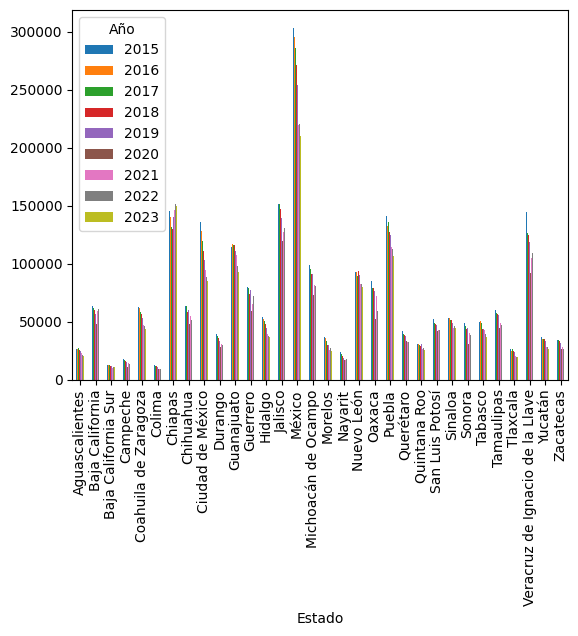

In [172]:
nacimientos.plot.bar()